# Análise de dados da H2 bet: Atividades de apostas, movimentações financeiras e perfis de clientes

A crescente competitividade no mercado de apostas online exige que as empresas se apoiem cada vez mais em dados para tomar decisões estratégicas. Nesse sentido, este projeto tem como objetivo analisar dados de atividades da H2 bet, buscando identificar comportamentos de jogadores, preferências de jogo, padrões financeiros e possíveis oportunidades de otimização de receita e retenção. Para esta análise, foram disponibilizados três conjuntos de dados (datasets) em formato CSV:

**casino_activity.csv** - Representa o resultado histórico de cada jogador em cada dia em cada jogo, com as seguintes colunas:
- <code>date</code>: Data em que o jogador jogou
- <code>clientid</code>: ID do cliente
- <code>Gameid</code>: O id único do jogo jogado
- <code>gamename</code>: Nome do jogo em que o cliente apostou
- <code>gametype</code>: Tipo do jogo
- <code>providername</code>: Nome do provedor responsável pelo jogo
- <code>betamount</code>: Valor total apostado pelo cliente nesse dia nesse jogo
- <code>betcount</code>: Quantidade de vezes que o cliente apostou nesse dia nesse jogo
- <code>winamount</code>: Valor total ganho pelo cliente nesse dia nesse jogo
- <code>ggramounr</code>: O

**client.csv** - Representa as informações de cada cliente único, com as seguintes colunas:
- <code>Id</code>: ID do cliente
- <code>Age</code>: idade do cliente
- <code>source</code>: Canal de entrada do cliente no momento do cadastro
- <code>Gender</code>: genero do cliente, sendo F para feminino e M para masculino.
- <code>Utm_source</code>: a utm source que representa a origem do cliente.
- <code>Utm_medium</code>: a utm medium que representa a origem do cliente.


**financial_activity.csv** - Representa as as movimentações financeiras dos clientes, com as seguintes colunas:
- <code>Date</code>: data operação realizada pelo cliente
- <code>Clientid</code>: id unico do cliente
- <code>Typeid</code>: id unico do tipo.
- <code>Typename</code>: tipo da operação, podendo ser Deposit (deposito) ou Withdrawal request Payment (saque).
- <code>Amount</code>: valor em reais da operação.

A proposta é integrar essas fontes de dados, tratando possíveis inconsistências e transformando-as em informações relevantes para diferentes áreas da empresa, como Marketing, Operações e Produto. Por exemplo, compreender quais canais de aquisição trazem clientes mais ativos, quais jogos geram maior receita ou quais grupos de clientes têm maior propensão a realizar saques frequentes são alguns dos insights que podem ser revelados.


</br>Neste notebook, desenvolvido no Google Colab, serão desenvolvidas as seguintes atividades:

- ***Conectar este notebook ao Google Drive*** para acessar as bases de dados.
- ***Carregar e explorar*** cada dataset, avaliando sua consistência, tipologia de variáveis e possíveis valores ausentes.
- ***Tratar e transformar as informações*** conforme necessário (ajustes de tipos de dados, criação de colunas derivadas, etc.).
- ***Analisar as informações para gerar visualizações e insights*** sobre comportamento de jogadores, preferências de jogos e movimentações financeiras.
- ***Sintetizar recomendações e oportunidades*** de melhoria para a empresa em questão, fundamentadas nas descobertas obtidas.

Com esse projeto, busca-se embasar decisões estratégicas relacionadas a aquisição, retenção e monetização dos clientes, contribuindo para um melhor posicionamento no mercado de apostas online.

## Setup e Leitura das Bases de Dados

Bibliotecas necessárias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

Acesso ao Google Drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


Carregando as bases de dados e criando os datasets

In [ ]:
casino_df = pd.read_csv('/content/drive/MyDrive/Cases/H2/casino_activity.csv')
client_df = pd.read_csv('/content/drive/MyDrive/Cases/H2/client.csv')
financial_df = pd.read_csv('/content/drive/MyDrive/Cases/H2/financial_activity.csv')

Verificando o carregamento dos dados

In [ ]:
casino_df.head()

,date,clientid,gameid,gamename,gametype,providername,betamount,winamount,ggramount
0,2024-03-14,1540884931,420033792,SUNNY FRUITS 2: HOLD AND WIN,SLOTS,PLAYSON,291.0,123.00,168
1,2024-01-11,1810759024,420032769,IMMORTAL WAYS 88 CHARMS,SLOTS,RUBYPLAY,5.0,21.74,-17
2,2024-11-24,64290527,420032769,IMMORTAL WAYS 88 CHARMS,SLOTS,RUBYPLAY,55.0,86.62,-32
3,2024-03-07,1711026941,420032769,IMMORTAL WAYS 88 CHARMS,SLOTS,RUBYPLAY,118.5,145.32,-27
4,2024-01-20,1094788315,420032769,IMMORTAL WAYS 88 CHARMS,SLOTS,RUBYPLAY,163.0,273.96,-111


In [ ]:
client_df.head()

,id,age,gender,lastnps,utm_source,utm_medium
0,1724828616,38,F,0,facebook,fb_campaign_1
1,2060681383,45,F,0,facebook,fb_campaign_1
2,195994197,21,F,0,facebook,fb_campaign_1
3,1600303453,76,F,0,facebook,fb_campaign_1
4,189246518,63,F,0,facebook,fb_campaign_1


In [ ]:
financial_df.head()

,date,clientid,typeid,typename,amount
0,2023-04-09,1360675460,3,Deposit,1.0
1,2023-04-09,1246832735,3,Deposit,20.0
2,2023-04-09,1200729656,3,Deposit,200.0
3,2023-04-09,1059156912,3,Deposit,10.0
4,2023-04-09,1129085755,3,Deposit,10.0


## Conhecendo os dataframes

Explorando as dimensões de cada dataframe

In [ ]:
print("\nQuantidade de linhas e colunas:")
print("casino_df:", casino_df.shape)
print("client_df:", client_df.shape)
print("financial_df:", financial_df.shape)


Quantidade de linhas e colunas:
casino_df: (3829294, 9)
client_df: (337701, 6)
financial_df: (2888944, 5)


Explorando a estrutura de dados de cada dataframe

In [ ]:
casino_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3829294 entries, 0 to 3829293
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          object 
 1   clientid      int64  
 2   gameid        int64  
 3   gamename      object 
 4   gametype      object 
 5   providername  object 
 6   betamount     float64
 7   winamount     float64
 8   ggramount     int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 262.9+ MB


A coluna 'date' aparece como object e não como datetime e precisa ser convertida.

In [ ]:
casino_df['date'] = pd.to_datetime(casino_df['date'], format='%Y-%m-%d')

Verificando a conversão.

In [ ]:
casino_df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3829294 entries, 0 to 3829293
Series name: date
Non-Null Count    Dtype         
--------------    -----         
3829294 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 29.2 MB


A conversão da coluna foi bem-sucedida.

In [ ]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337701 entries, 0 to 337700
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          337701 non-null  int64 
 1   age         337701 non-null  int64 
 2   gender      337701 non-null  object
 3   lastnps     337701 non-null  int64 
 4   utm_source  337701 non-null  object
 5   utm_medium  337701 non-null  object
dtypes: int64(3), object(3)
memory usage: 15.5+ MB


Nota-se que não há necessidade de converter os tipos das colunas listadas.

In [ ]:
financial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2888944 entries, 0 to 2888943
Data columns (total 5 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   clientid  int64  
 2   typeid    int64  
 3   typename  object 
 4   amount    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 110.2+ MB


A coluna date aparece como object e não como datetime.

In [ ]:
financial_df['date'] = pd.to_datetime(financial_df['date'], format='%Y-%m-%d')

Verificando a conversão.

In [ ]:
financial_df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2888944 entries, 0 to 2888943
Series name: date
Non-Null Count    Dtype         
--------------    -----         
2888944 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 22.0 MB


A conversão da coluna foi bem-sucedida.

### Valores nulos e duplicados

Contabilizando valores nulos em cada dataframe

In [ ]:
missing_values_casino = casino_df.isnull().sum()
missing_values_financial = financial_df.isnull().sum()
missing_values_client = client_df.isnull().sum()

Contabilizando valores duplicados em cada dataframe

In [ ]:
duplicates_count_casino = casino_df.duplicated().sum()
duplicates_count_financial = financial_df.duplicated().sum()
duplicates_count_client = client_df.duplicated().sum()

In [ ]:
print("Valores ausentes por coluna → casino_df:\n", missing_values_casino)
print("\nQuantidade de linhas duplicadas:", duplicates_count_casino)

Valores ausentes por coluna → casino_df:
 date            0
clientid        0
gameid          0
gamename        0
gametype        0
providername    0
betamount       0
winamount       0
ggramount       0
dtype: int64

Quantidade de linhas duplicadas: 0


In [ ]:
print("Valores ausentes por coluna → financial_df:\n", missing_values_financial)
print("\nQuantidade de linhas duplicadas:", duplicates_count_financial)

Valores ausentes por coluna → financial_df:
 date        0
clientid    0
typeid      0
typename    0
amount      0
dtype: int64

Quantidade de linhas duplicadas: 707955


Nesta base de dados temos recorrência de datas, clienteid, typeid, typename e amount, portanto não é um problema.

In [ ]:
print("Valores ausentes por coluna → client_df:\n", missing_values_client)
print("\nQuantidade de linhas duplicadas:", duplicates_count_client)

Valores ausentes por coluna → client_df:
 id            0
age           0
gender        0
lastnps       0
utm_source    0
utm_medium    0
dtype: int64

Quantidade de linhas duplicadas: 0


## Análise exploratória dos dados

### Análise do perfil dos clientes (client_df)

#### Distribuição etária dos clientes

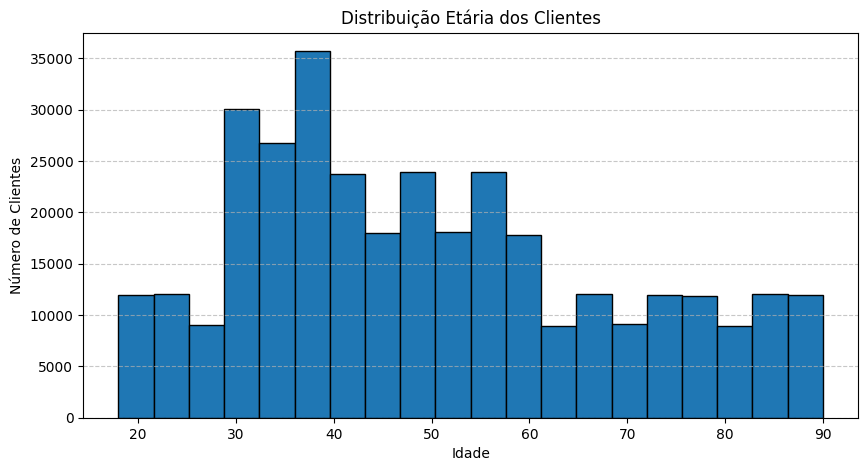

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(client_df['age'], bins=20, edgecolor='black')
plt.xlabel('Idade')
plt.ylabel('Número de Clientes')
plt.title('Distribuição Etária dos Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

O histograma mostra a distribuição etária dos clientes da H2 bet, e a análise pode ser feita com base nos seguintes pontos:

- Faixa etária predominante
  - A maior concentração de clientes está entre 30 e 40 anos, com um pico na faixa de 35 a 40 anos, indicando que esse é o público dominante.

- Distribuição geral
  - A distribuição é relativamente bem espalhada, mas com um declínio gradual conforme a idade aumenta.
  - Há um número considerável de clientes na faixa de 20 a 30 anos, e uma quantidade menor, mas ainda relevante, acima de 60 anos.

- Picos e quedas
  - O maior pico ocorre entre 35 e 40 anos.
  - Há uma leve queda em clientes na faixa de 20 a 25 anos, indicando menor adesão desse público.
  - A partir dos 60 anos, há uma redução no número de clientes, mas ainda há uma participação significativa.

- Possíveis interpretações estratégicas
  - A H2 bet pode focar campanhas e estratégias de retenção para clientes entre 30 e 40 anos, que parecem ser os mais ativos.
  - Pode ser interessante explorar formas de atrair um público mais jovem, entre 20 e 30 anos, caso esse grupo tenha um comportamento financeiro interessante.
  - A presença de um número razoável de clientes acima de 60 anos sugere que esse público não deve ser ignorado em estratégias de engajamento.

#### Proporção de gênero

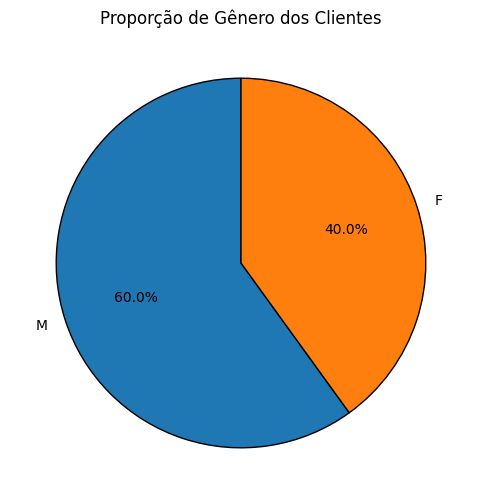

In [ ]:
gender_counts = client_df['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Proporção de Gênero dos Clientes')
plt.show()

O gráfico apresenta a proporção de gênero dos clientes cadastrados na H2 bet. A análise pode ser feita com base nos seguintes pontos:

- Distribuição de gênero
  - 60% dos clientes são do gênero masculino (M).
  - 40% dos clientes são do gênero feminino (F).
  - Há uma predominância de jogadores do gênero masculino, mas uma parcela significativa de clientes do gênero feminino também está presente.

- Possíveis implicações
  - A maior presença de clientes do gênero masculino pode indicar que esse público é mais atraído pelas apostas e jogos da H2 bet.
  - O público feminino, representando 40% dos clientes, ainda constitui uma fatia relevante do mercado, o que sugere oportunidades de marketing e engajamento direcionados a esse grupo.
  - Pode ser interessante avaliar se há diferenças no comportamento de apostas entre os gêneros, como valores apostados, tipos de jogos preferidos e padrões de depósito/saque.

- Ações estratégicas
  - Caso o objetivo seja equilibrar a participação dos gêneros, pode-se explorar campanhas promocionais ou conteúdos que atraiam mais jogadoras.
  - Se o comportamento financeiro dos clientes do gênero feminino for diferente, pode ser vantajoso oferecer experiências customizadas para esse público.

#### Canais de entrada mais usados (utm_source e utm_medium)

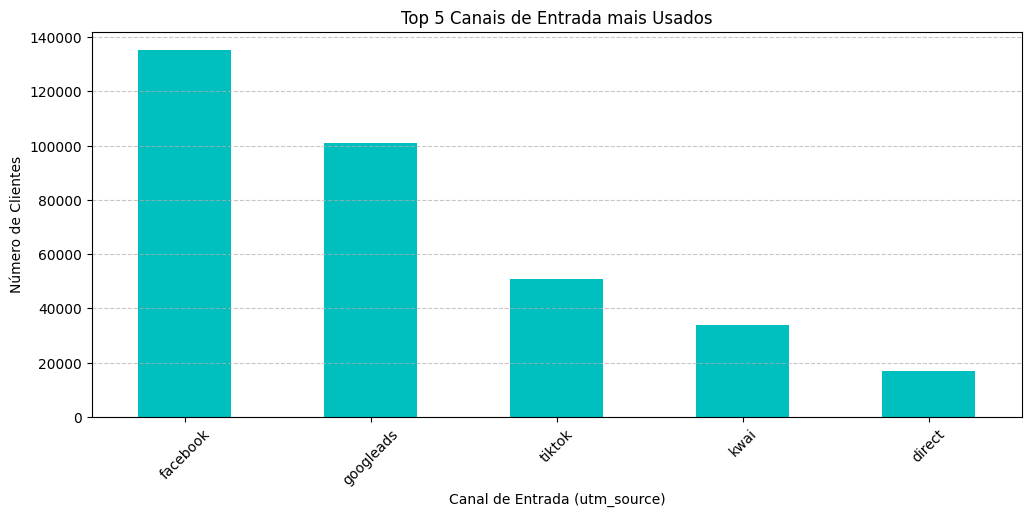

In [ ]:
utm_source_counts = client_df['utm_source'].value_counts().head(5)
plt.figure(figsize=(12, 5))
utm_source_counts.plot(kind='bar', color='c')
plt.xlabel('Canal de Entrada (utm_source)')
plt.ylabel('Número de Clientes')
plt.title('Top 5 Canais de Entrada mais Usados')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

O gráfico apresenta os cinco principais canais de entrada dos clientes, baseados na variável utm_source. A análise pode ser feita com base nos seguintes pontos:

- Principais fontes de aquisição de clientes
  - O Facebook é o canal que trouxe o maior número de clientes, ultrapassando 130.000 cadastros.
  - O Google Ads aparece em segundo lugar, com mais de 100.000 clientes.
  - O TikTok, Kwai e acesso direto (direct) representam volumes menores, mas ainda significativos.

- Destaque para redes sociais e tráfego pago
  - Os três primeiros canais (Facebook, Google Ads e TikTok) são fortemente associados a estratégias de tráfego pago e campanhas de marketing digital, indicando que a captação de clientes depende fortemente de anúncios pagos.
  - O acesso direto (direct) é o menor entre os cinco, sugerindo que uma pequena parte dos clientes chega a H2 bet sem passar por anúncios ou campanhas.

- Oportunidades e estratégias
  - Pode ser interessante analisar a qualidade dos clientes adquiridos por cada canal, verificando quais têm melhor retenção, maior ticket médio ou maior volume de apostas.
  - Dependendo dos custos de aquisição de clientes (CAC), pode ser vantajoso redistribuir investimentos entre esses canais para otimizar a captação.
  - A presença de TikTok e Kwai entre os principais canais sugere que vídeos curtos e campanhas visuais podem ser uma estratégia eficaz para atrair novos jogadores.

### Análise do comportamento das apostas (casino_df)

#### Jogos mais populares

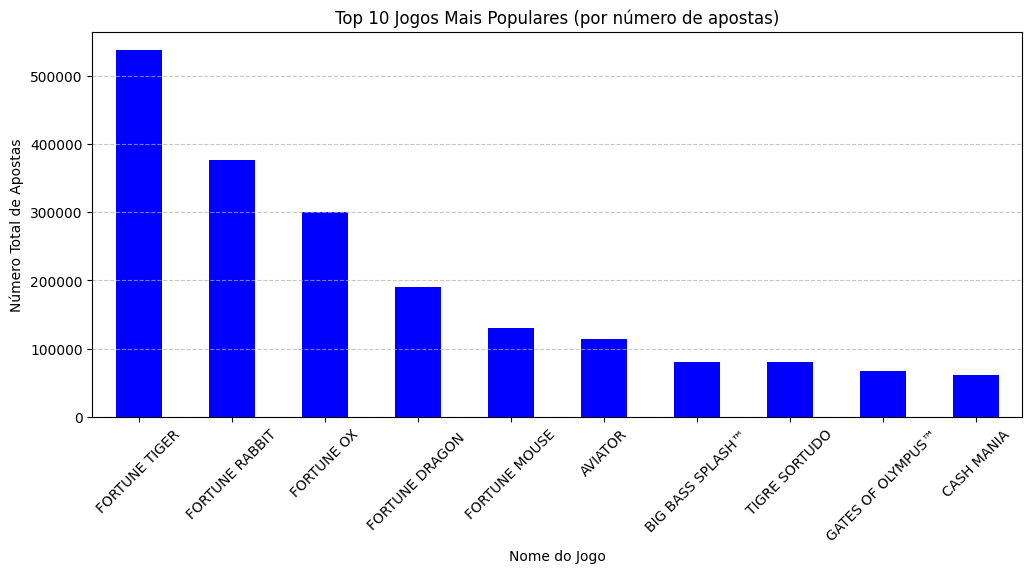

In [ ]:
# Contagem do número total de apostas por jogo
jogos_populares = casino_df.groupby('gamename')['betamount'].count().sort_values(ascending=False).head(10)

# Gráfico dos jogos mais populares
plt.figure(figsize=(12, 5))
jogos_populares.plot(kind='bar', color='b')
plt.xlabel('Nome do Jogo')
plt.ylabel('Número Total de Apostas')
plt.title('Top 10 Jogos Mais Populares (por número de apostas)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

O gráfico apresenta os 10 jogos mais populares da H2 bet, com base no número total de apostas registradas. A análise pode ser feita considerando os seguintes pontos:

- Jogos mais jogados
  - O jogo "FORTUNE TIGER" lidera com mais de 500.000 apostas, destacando-se como o mais popular entre os clientes.
  - Em seguida, "FORTUNE RABBIT" e "FORTUNE OX" apresentam um volume elevado de apostas, superando 300.000 cada.
  - Outros jogos como "FORTUNE DRAGON" e "FORTUNE MOUSE" também se destacam, ainda que com menor volume.
  - Jogos como "AVIATOR", "BIG BASS SPLASH™" e "GATES OF OLYMPUS™" apresentam um número significativo de apostas, mas bem abaixo dos líderes.

- Tendência de preferência
  - Jogos com a palavra "FORTUNE" aparecem em várias posições do ranking, indicando uma forte preferência por essa categoria ou temática.
  - Jogos de temática asiática, como tigres e dragões, parecem ter um apelo popular entre os jogadores.
  - "AVIATOR", um jogo de crash, também aparece entre os mais jogados, sugerindo que esse tipo de aposta tem relevância na H2 bet.

- Implicações estratégicas
  - Como alguns jogos apresentam um volume muito superior de apostas, pode ser interessante oferecer promoções e eventos especiais para os títulos mais populares, incentivando ainda mais o engajamento.
  - A presença predominante de jogos da linha "FORTUNE" sugere que há um público cativo para esse estilo, o que pode justificar a ampliação do catálogo de jogos semelhantes.
  - Jogos que possuem um volume moderado de apostas podem ser promovidos por meio de bônus ou rodadas grátis, para aumentar sua visibilidade e atratividade.

#### Tipos de jogos mais jogados

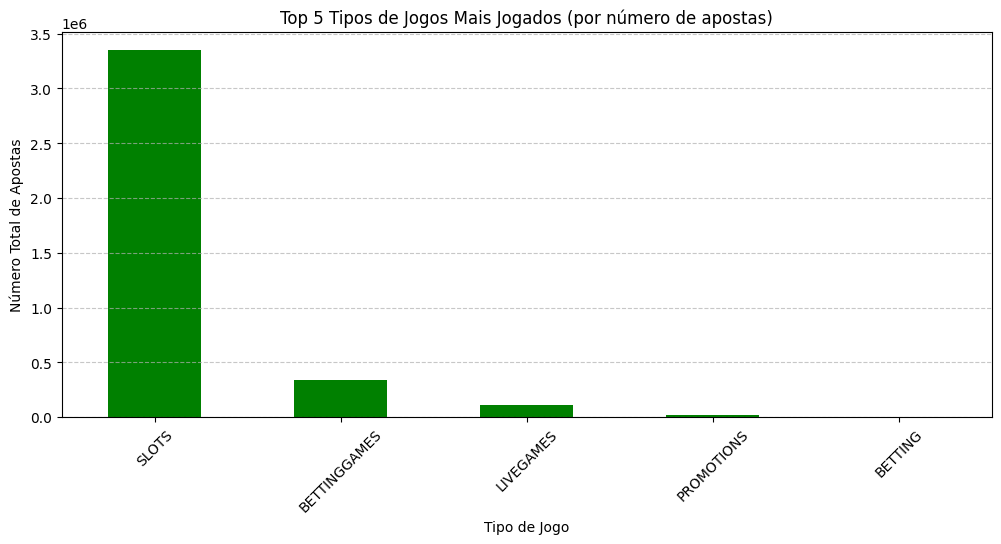

In [ ]:
# Contagem do número total de apostas por tipo de jogo
tipos_jogos_populares = casino_df.groupby('gametype')['betamount'].count().sort_values(ascending=False).head(5)

# Gráfico dos tipos de jogos mais jogados
plt.figure(figsize=(12, 5))
tipos_jogos_populares.plot(kind='bar', color='g')
plt.xlabel('Tipo de Jogo')
plt.ylabel('Número Total de Apostas')
plt.title('Top 5 Tipos de Jogos Mais Jogados (por número de apostas)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

O gráfico apresenta os cinco tipos de jogos mais jogados na H2 bet, considerando o número total de apostas registradas. A análise pode ser feita com base nos seguintes pontos:

- Domínio dos jogos de slot
  - O tipo de jogo SLOTS lidera com uma grande margem, ultrapassando 3 milhões de apostas.
  - O volume de apostas em slots é significativamente maior do que os demais tipos de jogos, indicando que essa categoria é a mais popular entre os jogadores.

- Outros tipos de jogos
  - BETTING GAMES aparece como o segundo mais jogado, mas ainda muito abaixo de slots.
  - LIVE GAMES ocupa a terceira posição, com um volume relativamente menor de apostas.
  - PROMOTIONS e BETTING aparecem com uma presença pequena, sugerindo que são menos atrativos para os jogadores.

- Tendências e preferências do público
  - O destaque absoluto dos slots sugere que os jogadores da H2 bet preferem jogos de mecânica simples, rápida e de alto volume de apostas.
  - Jogos ao vivo (LIVE GAMES) e jogos de apostas (BETTING GAMES) ainda apresentam uma participação relevante, indicando que há um público interessado em experiências mais interativas ou estratégicas.
  - O baixo volume de apostas em PROMOTIONS sugere que promoções associadas a jogos podem não estar sendo bem aproveitadas ou que os jogadores não percebem tanto valor nelas.

- Implicações estratégicas
  - A H2 bet pode investir mais em novos títulos de slots, promoções específicas para essa categoria e personalização da experiência dos jogadores que preferem esse tipo de jogo.
  - Pode ser interessante avaliar formas de aumentar a atratividade de outros tipos de jogos, como melhorando recompensas em apostas esportivas e jogos ao vivo.
  - Caso haja interesse em diversificar a retenção dos jogadores, estratégias para aumentar o engajamento nos demais tipos de jogos podem ser exploradas, como bonificações e experiências exclusivas.

#### Valor total apostado e ganho pelos clientes

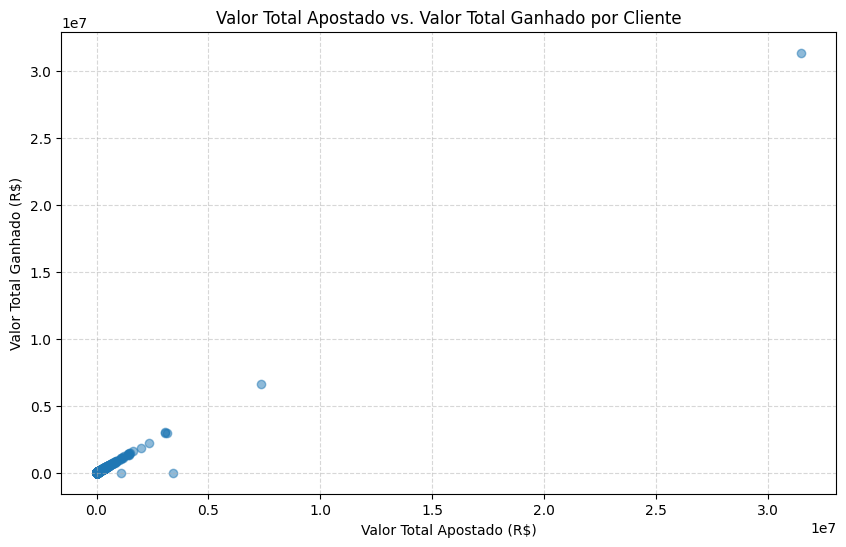

In [ ]:
# Cálculo do valor total apostado e ganho por cliente
valor_apostado_ganho = casino_df.groupby('clientid')[['betamount', 'winamount']].sum()

# Gráfico de dispersão do valor apostado vs. valor ganho
plt.figure(figsize=(10, 6))
plt.scatter(valor_apostado_ganho['betamount'], valor_apostado_ganho['winamount'], alpha=0.5)
plt.xlabel('Valor Total Apostado (R$)')
plt.ylabel('Valor Total Ganhado (R$)')
plt.title('Valor Total Apostado vs. Valor Total Ganhado por Cliente')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
valor_apostado_ganho.describe()

,betamount,winamount
count,1.757620e+05,1.757620e+05
mean,2.856784e+03,2.728853e+03
std,8.194686e+04,8.055650e+04
min,0.000000e+00,0.000000e+00
25%,1.700000e+01,6.280000e+00
50%,7.550000e+01,5.165000e+01
75%,4.182075e+02,3.724450e+02
max,3.149818e+07,3.134860e+07


A análise do valor total apostado e ganho pelos clientes pode ser feita com base no gráfico e nas estatísticas descritivas apresentadas.
- Distribuição dos valores apostados e ganhos
  - A média do valor apostado por cliente é R\$2.856,78, enquanto a média do valor ganho é R\$2.728,85, sugerindo que, em geral, os jogadores perdem uma pequena quantia ao longo do tempo.
  - O desvio padrão é alto, R\$81.946,86 para apostas e R\$80.556,50 para ganhos, indicando que há uma grande variação nos valores movimentados por cada cliente.
  - O percentil 50% (mediana) para apostas é R\$75,50, enquanto a mediana dos ganhos é R\$51,65, sugerindo que a maioria dos jogadores movimenta valores baixos.
  - O percentil 75% indica que 75% dos clientes apostam até R\$418,20 e ganham até R\$372,44, enquanto 25% dos clientes movimentam valores bem superiores.

- Clientes de alto valor e outliers
  - O máximo valor apostado por um único cliente foi R\$31.498.180, e o máximo valor ganho foi R\$31.348.600, indicando a presença de jogadores de altíssimo valor.
  - O gráfico de dispersão revela que há alguns outliers que apostam e ganham valores muito acima da média, o que pode impactar significativamente a rentabilidade da H2 bet.
  - A maioria dos clientes está concentrada no canto inferior esquerdo do gráfico, o que indica que a maior parte dos jogadores aposta e ganha quantias relativamente pequenas.

- Relação entre apostas e ganhos
  - A dispersão dos pontos sugere uma correlação positiva entre apostas e ganhos, ou seja, clientes que apostam mais tendem a ganhar mais.
  - Apesar da correlação, há uma leve tendência de que os valores apostados sejam ligeiramente superiores aos valores ganhos, o que se é esperado.

- Implicações estratégicas
  - A H2 bet pode identificar e segmentar jogadores de alto valor, oferecendo programas de fidelidade e vantagens exclusivas para os clientes que apostam grandes quantias.
  - Para os jogadores de menor volume, pode ser interessante oferecer incentivos para aumentar a recorrência de apostas, como bônus ou promoções personalizadas.
  - A grande dispersão dos valores sugere a necessidade de monitoramento de padrões de apostas, garantindo que estratégias de retenção sejam aplicadas de forma adequada para diferentes perfis de jogadores.

#### Clientes lucrativos vs. clientes que perderam mais do que ganharam

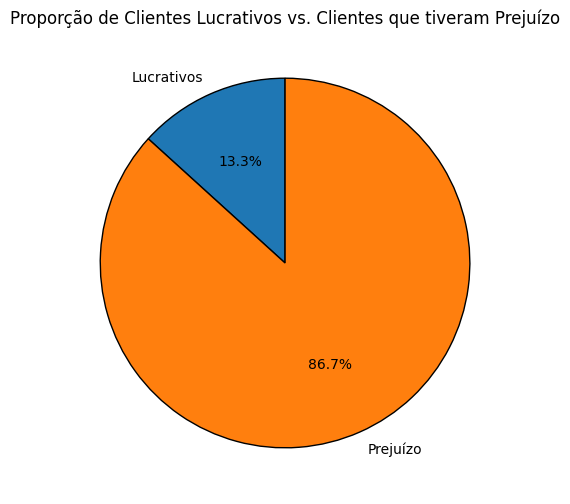

In [ ]:
# Cálculo do lucro ou prejuízo de cada cliente
valor_apostado_ganho['lucro'] = valor_apostado_ganho['winamount'] - valor_apostado_ganho['betamount']

# Contagem de clientes lucrativos e não lucrativos
clientes_lucrativos = valor_apostado_ganho[valor_apostado_ganho['lucro'] > 0].shape[0]
clientes_prejuizo = valor_apostado_ganho[valor_apostado_ganho['lucro'] <= 0].shape[0]

# Criar gráfico de distribuição entre clientes lucrativos e não lucrativos
plt.figure(figsize=(6, 6))
plt.pie([clientes_lucrativos, clientes_prejuizo], labels=['Lucrativos', 'Prejuízo'], autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Proporção de Clientes Lucrativos vs. Clientes que tiveram Prejuízo')
plt.show()

In [ ]:
# Estatísticas do lucro/prejuízo
valor_apostado_ganho['lucro'].describe()

,lucro
count,1.757620e+05
mean,-1.279311e+02
std,8.772961e+03
min,-3.402936e+06
25%,-4.954000e+01
50%,-1.409000e+01
75%,-3.960000e+00
max,4.674474e+04


A análise da proporção de clientes lucrativos vs. clientes que tiveram prejuízo pode ser feita com base no gráfico e nas estatísticas descritivas apresentadas.
- Proporção de clientes lucrativos e clientes com prejuízo
  - 86,7% dos clientes tiveram prejuízo, ou seja, perderam mais do que ganharam ao longo de suas apostas.
  - Apenas 13,3% dos clientes foram lucrativos, conseguindo ganhos superiores ao valor apostado.
  - Esse resultado é esperado, pois deve-se existir vantagem matemática sobre os jogadores, garantindo sua rentabilidade no longo prazo.

- Estatísticas descritivas do lucro/prejuízo
  - A média do lucro por cliente é negativa (-R\$127,93), confirmando que a maioria dos jogadores perde dinheiro ao apostar.
  - O percentil 50% (mediana) é de -R\$14,09, indicando que metade dos clientes perdeu pelo menos esse valor ao longo do tempo.
  - O percentil 75% é de -R\$3,96, sugerindo que a maioria dos clientes tem prejuízos relativamente pequenos.
  - O máximo lucro obtido por um cliente foi de R\$46.744,74, indicando que alguns jogadores conseguem ganhar valores elevados.
  - O máximo prejuízo registrado foi de -R\$3.402.936,00, sugerindo que alguns clientes podem perder quantias muito altas.

- Implicações estratégicas
  - A predominância de clientes com prejuízo confirma que a operação se comprova lucrativa, mas pode ser interessante entender o comportamento dos clientes lucrativos para identificar padrões.
  - Jogadores que tiveram grandes prejuízos podem ser monitorados para oferecer incentivos que os mantenham engajados, como bônus ou cashback.
  - A análise pode ser aprofundada ao verificar quanto tempo os clientes lucrativos permanecem ativos e se tendem a se tornar clientes com prejuízo ao longo do tempo.

### Análise do comportamento financeiro (financial_df)

#### Distribuição dos valores movimentados (depósitos e saques)

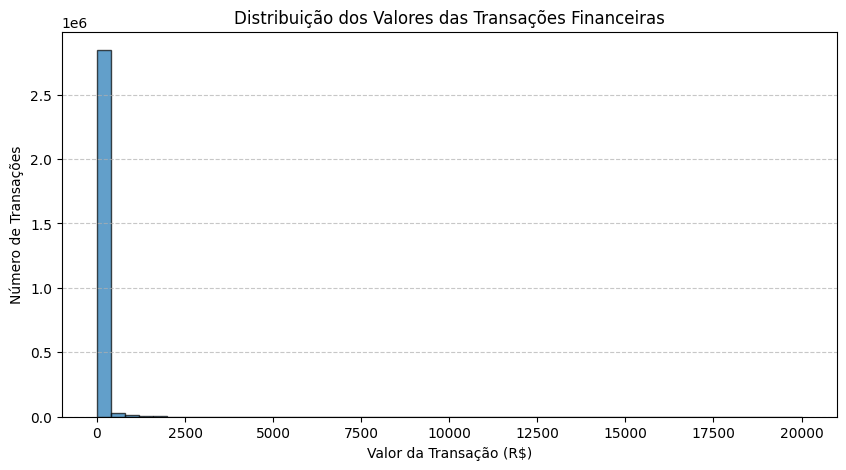

In [ ]:
# Cálculo da distribuição dos valores das transações financeiras
plt.figure(figsize=(10, 5))
plt.hist(financial_df['amount'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Valor da Transação (R$)')
plt.ylabel('Número de Transações')
plt.title('Distribuição dos Valores das Transações Financeiras')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Estatísticas descritivas dos valores movimentados
financial_df['amount'].describe()

,amount
count,2.888944e+06
mean,4.998144e+01
std,2.048246e+02
min,1.000000e+00
25%,1.000000e+01
50%,2.000000e+01
75%,4.000000e+01
max,2.000000e+04


A análise da distribuição dos valores das transações financeiras pode ser feita com base no gráfico e nas estatísticas descritivas apresentadas.
- Padrão da distribuição dos valores das transações
  - A maioria das transações está concentrada em valores baixos, próximos ao limite inferior do eixo X.
  - Existe um alto volume de transações pequenas, enquanto valores elevados são bem menos frequentes.
  - O gráfico apresenta uma assimetria à direita, indicando a presença de algumas transações de alto valor, mas em menor quantidade.

- Estatísticas descritivas
  - O valor médio das transações é R\$49,98, mas a mediana é R\$20,00, indicando que a distribuição é fortemente influenciada por transações de valores elevados.
  - O percentil 25% é de R\$10,00, enquanto o percentil 75% é de R\$40,00, confirmando que a maioria das transações ocorre dentro dessa faixa.
  - O valor máximo registrado foi de R\$20.000,00, o que pode indicar um pequeno grupo de jogadores que movimenta quantias elevadas.
  - O desvio padrão de R\$204,82 indica uma variação significativa entre os valores das transações, reforçando a presença de alguns outliers.

- Implicações estratégicas
  - A grande concentração de transações em valores baixos sugere que muitos jogadores preferem movimentações financeiras menores e recorrentes.
  - As transações de valores elevados devem ser analisadas separadamente, pois podem estar associadas a jogadores VIP ou clientes que realizam apostas mais altas.
  - A H2 bet pode considerar estratégias para incentivar depósitos maiores, como bônus progressivos para jogadores que adicionam valores mais altos à conta.

#### Comparação entre volume de depósitos e volume de saques

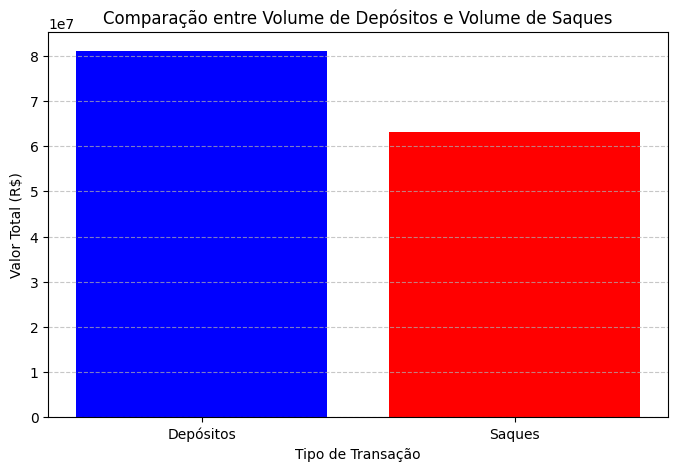

In [ ]:
# Separação dos depósitos e saques
depositos = financial_df[financial_df['typename'] == 'Deposit']['amount'].sum()
saques = financial_df[financial_df['typename'] == 'Withdrawal request Payment']['amount'].sum()

# Criar gráfico comparativo entre depósitos e saques
plt.figure(figsize=(8, 5))
plt.bar(['Depósitos', 'Saques'], [depositos, saques], color=['blue', 'red'])
plt.xlabel('Tipo de Transação')
plt.ylabel('Valor Total (R$)')
plt.title('Comparação entre Volume de Depósitos e Volume de Saques')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Retornar os valores totais para análise
print("Total (em R$) de depósitos realizados: R$",round(depositos,2))
print("Total (em R$) de saques realizados: R$",round(saques,2))

Total (em R$) de depósitos realizados: R$ 81159502.97
Total (em R$) de saques realizados: R$ 63234079.94


A análise da comparação entre volume de depósitos e volume de saques pode ser feita com base no gráfico e nos valores apresentados.
- Diferença entre depósitos e saques
  - O total de depósitos realizados foi de R\$81.159.502,97.
  - O total de saques realizados foi de R\$63.234.079,94.
  - O valor total de depósitos é 28,3% maior do que o valor total de saques, indicando que existe um saldo positivo para a empresa.

- Fluxo financeiro
  - Há um fluxo de caixa positivo, já que mais dinheiro entra por meio de depósitos do que sai via saques.
  - Essa diferença pode representar o lucro operacional antes de considerar custos e despesas da plataforma.
  - A taxa de retenção do dinheiro apostado é um indicador fundamental para entender a saúde financeira da operação.

- Implicações estratégicas
  - O volume de saques é relativamente alto, o que sugere que muitos jogadores conseguem recuperar parte do valor apostado.
  - É possível explorar estratégias para reduzir a taxa de saques, como oferecer bônus e incentivos para reinvestimento dos ganhos antes do saque.
  - Pode ser interessante analisar se os clientes que sacam frequentemente também realizam novos depósitos ou se tendem a abandonar a plataforma.

#### Padrões de comportamento financeiro dos jogadores

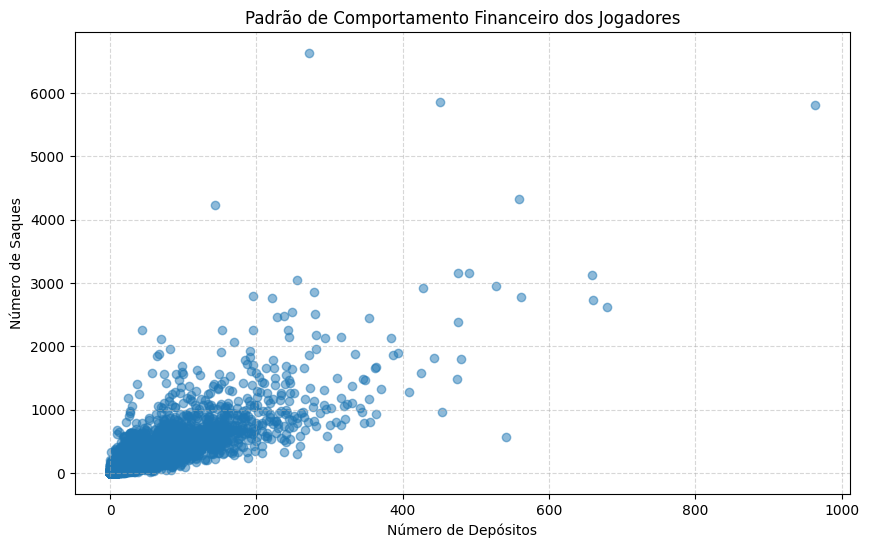

In [ ]:
# Cálculo do número de depósitos e saques por cliente
transacoes_por_cliente = financial_df.groupby('clientid')['typename'].value_counts().unstack().fillna(0)

# Renomear colunas para melhor interpretação
transacoes_por_cliente.columns = ['Saques', 'Depósitos']

# Criar gráfico de dispersão para analisar padrões financeiros dos jogadores
plt.figure(figsize=(10, 6))
plt.scatter(transacoes_por_cliente['Depósitos'], transacoes_por_cliente['Saques'], alpha=0.5)
plt.xlabel('Número de Depósitos')
plt.ylabel('Número de Saques')
plt.title('Padrão de Comportamento Financeiro dos Jogadores')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Estatísticas descritivas do número de transações por cliente
transacoes_por_cliente.describe()

,Saques,Depósitos
count,184712.000000,184712.000000
mean,13.296586,2.343676
std,75.985724,13.449379
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,4.000000,1.000000
max,6626.000000,963.000000


A análise do padrão de comportamento financeiro dos jogadores pode ser feita com base no gráfico de dispersão e nas estatísticas descritivas apresentadas.
- Distribuição dos depósitos e saques por cliente
  - A maioria dos jogadores está concentrada no canto inferior esquerdo do gráfico, indicando que a maior parte realiza poucos depósitos e poucos saques.
  - Há uma correlação positiva entre o número de depósitos e o número de saques, ou seja, jogadores que fazem mais depósitos tendem a realizar mais saques.
  - Alguns outliers apresentam um número muito elevado de transações, chegando a 963 depósitos e 6.626 saques, o que pode indicar um comportamento financeiro atípico ou jogadores VIP.

- Estatísticas descritivas
  - O número médio de saques por cliente é 13,3, enquanto a média de depósitos é 2,34, sugerindo que os jogadores realizam mais saques do que depósitos.
  - A mediana para saques é 1,00, indicando que metade dos jogadores realiza no máximo um saque.
  - A mediana para depósitos é 0,00, sugerindo que muitos clientes jogam sem realizar depósitos frequentes ou que os depósitos são concentrados em um pequeno grupo de usuários.
  - O percentil 75% mostra que 75% dos clientes realizam até 4 saques e apenas 1 depósito, reforçando a tendência de saques serem mais frequentes do que depósitos.

- Perfis de jogadores identificados
  - Jogadores ocasionais: A maioria dos jogadores realiza poucos depósitos e saques, indicando que apostam com valores baixos e fazem retiradas esporádicas.
  - Jogadores recorrentes: Um grupo menor de jogadores realiza transações frequentes, movimentando mais dinheiro nos jogos.
  - Jogadores VIP e possíveis outliers: Alguns usuários têm um número muito elevado de saques e depósitos, o que pode indicar um comportamento estratégico, como rodar grandes volumes de dinheiro, ou até mesmo sinais de lavagem de dinheiro que precisam ser monitorados.

- Implicações estratégicas
  - é possível incentivar mais depósitos recorrentes por meio de bônus progressivos, para aumentar a retenção de dinheiro dentro da plataforma.
  - Clientes que realizam muitos saques sem depósitos podem ser alvo de campanhas para engajá-los a reinvestir seus ganhos nos próprios jogos da H2 bet.
  - A presença de outliers com milhares de transações deve ser monitorada, pois pode indicar jogadores VIPs ou possíveis riscos de fraude.

### Identificação de clientes Ativos X Inativos

O objetivo é:
- Determinar quantos clientes ainda estão ativos (fizeram apostas nos últimos 30 dias).
- Identificar clientes que se tornaram inativos (não jogaram no último mês).

Será feita uma análise baseada na data da última aposta de cada cliente para classificar os jogadores como ativos ou inativos.

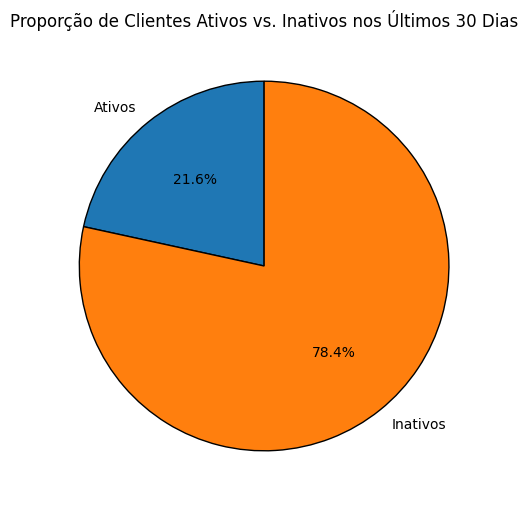

In [ ]:
from datetime import datetime, timedelta

# Definir o período de análise (últimos 30 dias)
data_atual = casino_df['date'].max()  # Data mais recente no dataset
limite_data = data_atual - timedelta(days=30)

# Identificar a última data de aposta de cada cliente
ultima_aposta_por_cliente = casino_df.groupby('clientid')['date'].max()

# Classificar clientes como ativos ou inativos
clientes_ativos = ultima_aposta_por_cliente[ultima_aposta_por_cliente >= limite_data].count()
clientes_inativos = ultima_aposta_por_cliente[ultima_aposta_por_cliente < limite_data].count()

# Criar gráfico para visualizar a proporção de clientes ativos e inativos
plt.figure(figsize=(6, 6))
plt.pie([clientes_ativos, clientes_inativos], labels=['Ativos', 'Inativos'], autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Proporção de Clientes Ativos vs. Inativos nos Últimos 30 Dias')
plt.show()

In [ ]:
print("O número total de clientes ATIVOS, é: ",clientes_ativos)
print("O número total de clientes INATIVOS, é:",clientes_inativos)

O número total de clientes ATIVOS, é:  37936
O número total de clientes INATIVOS, é: 137826


A análise da retenção de clientes com base no gráfico e nos valores calculados permite identificar os seguintes pontos:
- Distribuição de Clientes Ativos e Inativos
  - O número total de clientes ativos nos últimos 30 dias é 37.936 (21,6%).
  - O número total de clientes inativos (que não jogaram no último mês) é 137.826 (78,4%).
  - A maior parte dos jogadores se torna inativa após um certo período, sugerindo que a retenção da plataforma de jogos pode ser melhorada.

- Interpretação dos Resultados
  - O fato de apenas 21,6% dos clientes permanecerem ativos indica que muitos jogadores experimentam a plataforma, mas não continuam jogando a longo prazo.
  - A taxa de inatividade de 78,4% pode indicar que há baixa fidelização, o que pode ser causado por vários fatores, como falta de incentivos para continuar jogando, concorrência com outros jogos online, ou experiência do usuário.
  - Pode ser interessante analisar quanto tempo, em média, um jogador permanece ativo antes de parar de apostar.

- Implicações Estratégicas
  - Programas de fidelidade podem ser implementados para incentivar os jogadores a retornarem à plataforma, como bônus para jogadores recorrentes ou desafios semanais.
  - Campanhas de reativação podem ser feitas com promoções direcionadas a clientes inativos, incentivando-os a voltar a jogar.
  - É possível oferecer bônus progressivos para jogadores que fazem depósitos frequentes, garantindo que continuem ativos por mais tempo.

#### Tempo Médio de Atividade dos Clientes

O objetivo é calcular:
- O tempo médio que um cliente permanece ativo antes de se tornar inativo.
- Distribuição do tempo de atividade dos jogadores.
- Se há padrões de clientes que permanecem por mais tempo na plataforma.

Para isso, será analisado o tempo entre a primeira e a última aposta de cada jogador.

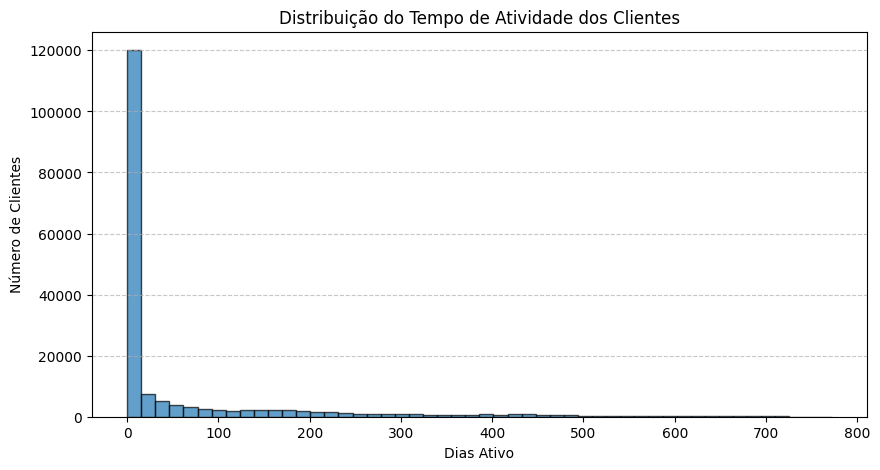

In [ ]:
# Calcular o tempo de atividade de cada cliente (última aposta - primeira aposta)
tempo_atividade = casino_df.groupby('clientid')['date'].agg(['min', 'max'])
tempo_atividade['dias_ativo'] = (tempo_atividade['max'] - tempo_atividade['min']).dt.days

# Estatísticas descritivas do tempo de atividade dos clientes
estatisticas_atividade = tempo_atividade['dias_ativo'].describe()

# Criar um histograma para visualizar a distribuição do tempo de atividade dos clientes
plt.figure(figsize=(10, 5))
plt.hist(tempo_atividade['dias_ativo'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Dias Ativo')
plt.ylabel('Número de Clientes')
plt.title('Distribuição do Tempo de Atividade dos Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Retornar estatísticas descritivas do tempo de atividade
estatisticas_atividade

,dias_ativo
count,175762.000000
mean,58.398152
std,123.657311
min,0.000000
25%,0.000000
50%,0.000000
75%,44.000000
max,772.000000


A análise da distribuição do tempo de atividade dos clientes pode ser feita com base no gráfico e nos valores estatísticos calculados.
- Distribuição do Tempo de Atividade
  - A maioria dos clientes tem um tempo de atividade muito curto, com um número significativo de jogadores permanecendo ativos por apenas um ou poucos dias.
  - O gráfico apresenta uma distribuição altamente assimétrica, com um pico acentuado próximo a zero e uma cauda longa, indicando que poucos clientes continuam ativos por longos períodos.
  - O tempo máximo de atividade registrado é 772 dias, mostrando que alguns jogadores permanecem engajados na plataforma por mais de dois anos.

- Estatísticas Descritivas
  - A média de tempo de atividade é de 58,4 dias, mas esse valor é influenciado pelos jogadores mais antigos que continuam ativos.
  - A mediana (50%) do tempo de atividade é de 0 dias, indicando que a maioria dos clientes joga apenas no primeiro dia e não retorna.
  - 25% dos clientes (percentil 25%) têm 0 dias de atividade, ou seja, uma parte significativa dos jogadores aposta apenas uma vez.
  - 75% dos clientes jogam por até 44 dias, sugerindo que, embora a maioria pare rapidamente, ainda há uma parcela que se mantém ativa por mais tempo.

- Interpretação e Possíveis Causas
  - O alto número de clientes com tempo de atividade próximo de zero pode indicar que muitos jogadores se cadastram, fazem uma ou poucas apostas e não voltam.
  - A retenção inicial parece ser um desafio, sugerindo que a plataforma pode não estar conseguindo manter novos jogadores engajados após sua primeira experiência.
  - Os clientes que permanecem ativos por mais tempo podem representar um público mais fiel, que pode ser incentivado a continuar jogando com bônus progressivos, desafios ou programas de fidelidade.

- Implicações Estratégicas
  - Focar na retenção inicial: Criar incentivos para que novos jogadores voltem a jogar nos primeiros dias pode aumentar o tempo médio de atividade.
  - Oferecer bônus progressivos: Recompensas para jogadores que continuam ativos por mais dias podem estimular o engajamento contínuo.
  - Segmentar campanhas para clientes de diferentes perfis: Clientes que jogam pouco podem ser incentivados com bônus de ativação, enquanto clientes mais frequentes podem ser recompensados por sua lealdade.

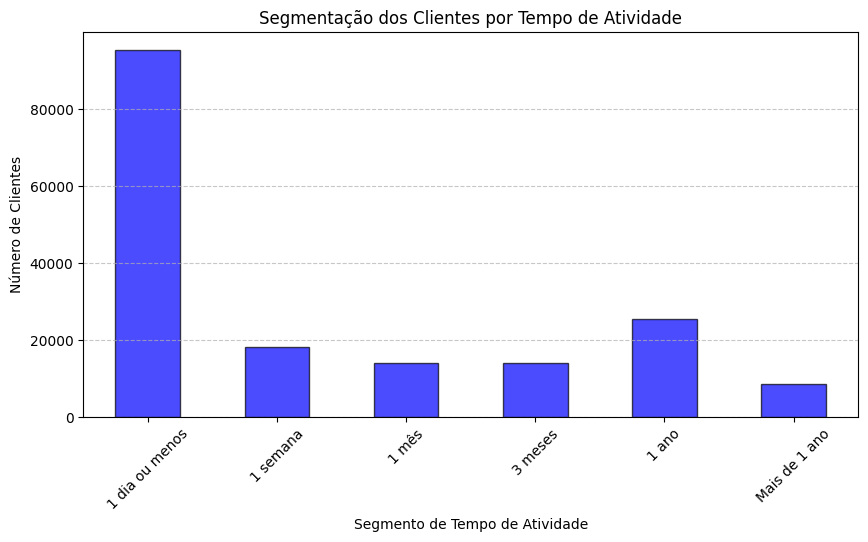

In [ ]:
# Calcular o tempo de atividade de cada cliente (última aposta - primeira aposta)
tempo_atividade = casino_df.groupby('clientid')['date'].agg(['min', 'max'])
tempo_atividade['dias_ativo'] = (tempo_atividade['max'] - tempo_atividade['min']).dt.days

# Definir categorias de segmentação com base no tempo de atividade
bins = [-1, 0, 7, 30, 90, 365, tempo_atividade['dias_ativo'].max()]
labels = ['1 dia ou menos', '1 semana', '1 mês', '3 meses', '1 ano', 'Mais de 1 ano']

# Criar uma nova coluna de segmentação
tempo_atividade['segmento'] = pd.cut(tempo_atividade['dias_ativo'], bins=bins, labels=labels)

# Contagem de clientes por segmento
segmentacao_clientes = tempo_atividade['segmento'].value_counts().sort_index()

# Criar gráfico de barras para visualizar a segmentação
plt.figure(figsize=(10, 5))
segmentacao_clientes.plot(kind='bar', color='b', edgecolor='black', alpha=0.7)
plt.xlabel('Segmento de Tempo de Atividade')
plt.ylabel('Número de Clientes')
plt.title('Segmentação dos Clientes por Tempo de Atividade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A análise da segmentação dos clientes por tempo de atividade pode ser feita com base no gráfico apresentado.
- Distribuição dos Clientes por Tempo de Atividade
  - A maior parte dos clientes (mais de 85.000 jogadores) joga por apenas 1 dia ou menos e não retorna.
  - O número de clientes cai significativamente nos segmentos seguintes, indicando que a retenção inicial é um dos maiores desafios.
  - Há uma quantidade menor de clientes que permanecem ativos por períodos mais longos, mas um grupo significativo atinge 1 ano de atividade, sugerindo um público fiel.

- Interpretação dos Resultados
  - A alta evasão inicial indica que muitos jogadores entram na plataforma, mas não encontram incentivos suficientes para continuar jogando.
  - A retenção melhora em períodos intermediários (1 mês a 1 ano), sugerindo que jogadores que superam os primeiros dias podem ter maior probabilidade de continuar apostando.
  - Os jogadores que atingem 1 ano de atividade podem representar um público mais engajado e lucrativo, valendo a pena estratégias para mantê-los ativos por mais tempo.

- Implicações Estratégicas
  - Foco na retenção inicial: É possível pode implementar bônus progressivos ou missões diárias para incentivar os novos jogadores a retornarem nos primeiros dias.
  - Segmentação de campanhas de reativação: Ofertas específicas podem ser direcionadas a jogadores que abandonam a plataforma logo após o primeiro dia.
  - Programas de fidelização para clientes de longo prazo: Jogadores que chegam ao segmento de 1 ano ou mais devem ser incentivados a continuar ativos, por meio de programas VIP ou recompensas exclusivas.

#### Cálculo da Lifetime Value (LTV) dos clientes

Objetivo da análise

- Determinar a receita média gerada por cliente ao longo de sua permanência na plataforma.
- Comparar a LTV entre diferentes segmentos de jogadores para entender quais grupos são mais lucrativos.
- Identificar oportunidades para aumentar a retenção e a lucratividade de diferentes perfis de jogadores.

O cálculo do Lifetime Value (LTV) será feito com base na seguinte fórmula:

$$
LTV = \frac{\text{Receita Total (Apostas - Ganhos)}}{\text{Número Total de Clientes}}
$$


Em seguida, será analisado o LTV médio por segmento de tempo de atividade, para entender quais grupos de jogadores geram mais receita para a empresa.


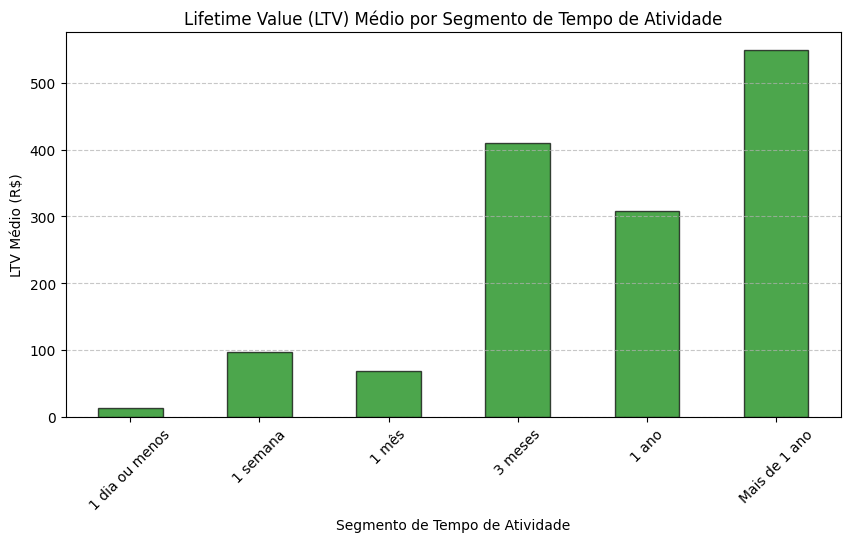

In [ ]:
# Cálculo do valor total perdido por cada cliente (Apostas - Ganhos)
receita_por_cliente = casino_df.groupby('clientid')[['betamount', 'winamount']].sum()
receita_por_cliente['receita'] = receita_por_cliente['betamount'] - receita_por_cliente['winamount']

# Cálculo do LTV médio geral
ltv_geral = receita_por_cliente['receita'].sum() / receita_por_cliente.shape[0]

# Unir com a segmentação de tempo de atividade
ltv_por_segmento = tempo_atividade.join(receita_por_cliente, on='clientid')

# Cálculo do LTV médio por segmento de tempo de atividade
ltv_por_segmento = ltv_por_segmento.groupby('segmento', observed=False)['receita'].mean().sort_index()

# Criar gráfico para visualizar o LTV médio por segmento
plt.figure(figsize=(10, 5))
ltv_por_segmento.plot(kind='bar', color='g', edgecolor='black', alpha=0.7)
plt.xlabel('Segmento de Tempo de Atividade')
plt.ylabel('LTV Médio (R$)')
plt.title('Lifetime Value (LTV) Médio por Segmento de Tempo de Atividade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A análise do Lifetime Value (LTV) médio por segmento de tempo de atividade pode ser feita com base no gráfico apresentado.
- Relação entre Tempo de Atividade e LTV
  - Clientes que permanecem ativos por mais tempo geram maior receita para a H2 bet.
  - Jogadores que permanecem por mais de 1 ano têm o maior LTV, ultrapassando R\$500,00 em média.
  - Clientes com tempo de atividade de 3 meses a 1 ano também apresentam um LTV elevado, variando entre R\$300,00 e R\$400,00.
  - Clientes que jogam apenas 1 dia têm um LTV muito baixo, quase insignificante em comparação com os segmentos de longo prazo.

- Interpretação dos Resultados
  - O LTV aumenta à medida que o tempo de atividade do cliente cresce, indicando que retenção é um fator essencial para a lucratividade da empresa.
  - Os jogadores que jogam por mais de 1 ano são os mais valiosos, o que sugere que o foco na fidelização pode trazer um grande retorno financeiro.
  - Os clientes que jogam apenas por um curto período não geram receita significativa, reforçando a necessidade de estratégias para prolongar sua permanência na plataforma.

- Implicações Estratégicas
  - Focar na retenção dos primeiros dias: Clientes que jogam apenas um dia possuem um LTV muito baixo. Incentivos como bônus progressivos podem ajudar a reter esses jogadores por mais tempo.
  - Programas de fidelidade para clientes de longo prazo: Como os jogadores mais antigos geram muito mais receita, ofertas VIP, cashback e eventos exclusivos podem fortalecer esse relacionamento.
  - Campanhas segmentadas para grupos intermediários: Jogadores com 1 a 3 meses de atividade ainda têm potencial para crescer, e ações específicas para esse público podem incentivar sua permanência.

### Análise de Riscos e Detecção de Fraudes

#### Detecção de Clientes com Apostas Extremamente Altas

Para começar, será analisado se existem jogadores que apostam valores muito acima da média, pois esse pode ser um comportamento suspeito.

A análise incluirá:
  - Distribuição dos valores apostados para entender o comportamento geral.
  - Identificação de outliers (valores extremos de apostas).
  - Perfis dos jogadores que mais apostam, verificando se há padrões incomuns.

Agora, será gerado um histograma dos valores apostados para visualizar a distribuição.

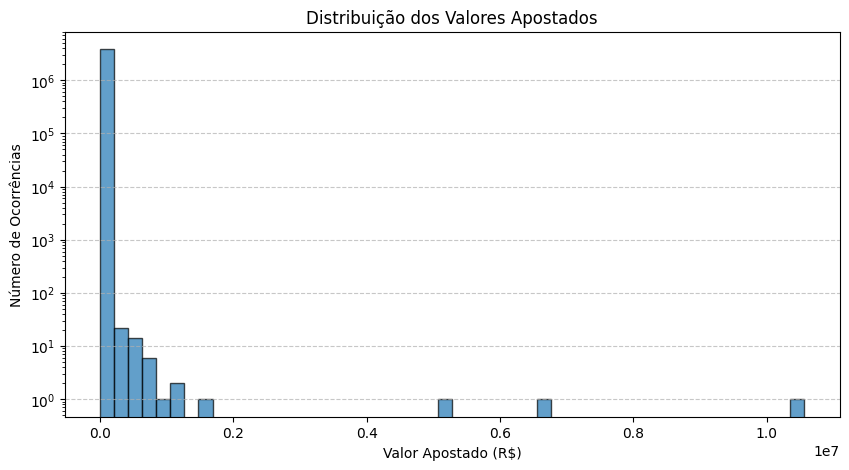

In [ ]:
import matplotlib.pyplot as plt

# Criar histograma para visualizar a distribuição dos valores apostados
plt.figure(figsize=(10, 5))
plt.hist(casino_df['betamount'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Valor Apostado (R$)')
plt.ylabel('Número de Ocorrências')
plt.title('Distribuição dos Valores Apostados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log')  # Usar escala logarítmica para visualizar melhor os outliers
plt.show()

In [ ]:
# Estatísticas descritivas dos valores apostados
estatisticas_apostas = casino_df['betamount'].describe()

# Identificação de outliers (acima do percentil 99)
limite_outlier = casino_df['betamount'].quantile(0.99)
outliers_apostas = casino_df[casino_df['betamount'] > limite_outlier]

In [ ]:
# Exibir estatísticas descritivas e os principais outliers
from IPython.display import display

display(estatisticas_apostas)

,betamount
count,3.829294e+06
mean,1.311244e+02
std,7.273517e+03
min,0.000000e+00
25%,5.200000e+00
50%,1.750000e+01
75%,5.760000e+01
max,1.056439e+07


In [ ]:
display(outliers_apostas.head(10))  # Mostrar os 10 maiores outliers

,date,clientid,gameid,gamename,gametype,providername,betamount,winamount,ggramount
6,2024-05-25,24259418,420032769,IMMORTAL WAYS 88 CHARMS,SLOTS,RUBYPLAY,5513.0,5067.72,445
8,2024-11-10,179374263,426639362,SNOOP DOGG DOLLARS,SLOTS,BGAMING,2614.5,673.56,1941
67,2024-11-19,2185610939,3001090,FORTUNE OX,SLOTS,PG SOFT,1725.0,2119.90,-395
115,2024-05-30,78617016,3001090,FORTUNE OX,SLOTS,PG SOFT,3101.0,2849.70,251
194,2024-06-02,1320323667,3001090,FORTUNE OX,SLOTS,PG SOFT,2827.5,2843.30,-16
228,2024-11-14,177461022,3001090,FORTUNE OX,SLOTS,PG SOFT,3982.0,2918.95,1063
252,2024-08-07,56194455,3001090,FORTUNE OX,SLOTS,PG SOFT,2978.0,3299.20,-321
270,2024-02-11,22485316,3001090,FORTUNE OX,SLOTS,PG SOFT,2074.0,1853.70,220
314,2024-03-30,36728333,3001090,FORTUNE OX,SLOTS,PG SOFT,2686.5,2500.15,186
330,2024-11-05,1482087949,3001090,FORTUNE OX,SLOTS,PG SOFT,2435.5,2388.30,47


A análise do histograma e das estatísticas descritivas dos valores apostados permite identificar padrões de comportamento dos jogadores, bem como detectar possíveis anomalias ou comportamentos suspeitos.
- Distribuição Geral dos Valores Apostados
  - O valor médio apostado por rodada é de aproximadamente R\$131,12, mas o percentil 75% é de apenas R\$57,60, indicando que a maioria dos jogadores aposta valores baixos.
  - O valor máximo apostado registrado foi de R\$10.564.390,00, o que é extremamente alto em comparação com a média e a distribuição geral dos jogadores.
  - O desvio padrão é muito alto (R\$7.273,52), sugerindo uma grande dispersão nos valores apostados, com alguns jogadores movimentando quantias muito acima da média.

- Interpretação do Histograma
  - A maioria das apostas está concentrada próxima ao zero, confirmando que a maior parte dos jogadores faz apostas pequenas e frequentes.
  - A escala logarítmica permite visualizar que há poucos jogadores com apostas extremamente altas, mas esses jogadores representam valores significativamente superiores à média.
  - Os outliers aparecem claramente no gráfico, com valores muito acima da distribuição normal.

- Identificação de Outliers e Jogadores com Apostas Altas
  - O percentil 99 foi usado para definir um limite de outlier, o que indica que apostas acima de aproximadamente R\$5.513,00 são raras e podem ser consideradas atípicas.
  - Os jogadores com apostas acima desse valor devem ser analisados individualmente para entender se são jogadores VIPs, estratégias de apostas específicas ou possíveis comportamentos suspeitos.

Os principais outliers identificados apostaram valores elevados em jogos de slots, como "IMMORTAL WAYS 88 CHARMS" e "FORTUNE OX", que podem permitir apostas mais altas.

#### Análise da Relação entre Apostas Altas e Frequência de Vitórias

O objetivo dessa análise é verificar se os jogadores que fazem apostas muito acima da média também apresentam uma taxa de vitória anormalmente alta. Isso pode indicar exploração de padrões favoráveis de jogos ou até possíveis fraudes.

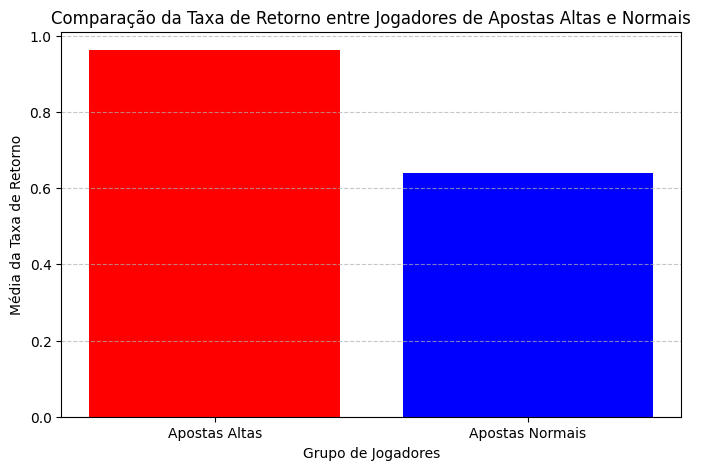

In [ ]:
# Calcular a taxa de retorno por jogador (valor ganho / valor apostado)
taxa_retorno = casino_df.groupby('clientid')[['betamount', 'winamount']].sum()
taxa_retorno['taxa_retorno'] = taxa_retorno['winamount'] / taxa_retorno['betamount']

# Remover casos em que a aposta foi zero para evitar divisão por zero
taxa_retorno = taxa_retorno[taxa_retorno['betamount'] > 0]

# Calcular estatísticas gerais da taxa de retorno
estatisticas_taxa_retorno = taxa_retorno['taxa_retorno'].describe()

# Definir o limite para apostas altas (percentil 99)
limite_aposta_alta = casino_df['betamount'].quantile(0.99)

# Identificar jogadores de apostas elevadas
jogadores_apostas_altas = casino_df.groupby('clientid')['betamount'].sum()
jogadores_apostas_altas = jogadores_apostas_altas[jogadores_apostas_altas > limite_aposta_alta]

# Comparar a taxa de retorno entre jogadores normais e jogadores de apostas elevadas
taxa_retorno_jogadores_altos = taxa_retorno.loc[jogadores_apostas_altas.index]
taxa_retorno_normais = taxa_retorno.loc[~taxa_retorno.index.isin(jogadores_apostas_altas.index)]

# Calcular médias de taxa de retorno
media_taxa_retorno_altos = taxa_retorno_jogadores_altos['taxa_retorno'].mean()
media_taxa_retorno_normais = taxa_retorno_normais['taxa_retorno'].mean()

# Criar gráfico para comparar a taxa de retorno média entre os grupos
plt.figure(figsize=(8, 5))
plt.bar(['Apostas Altas', 'Apostas Normais'], [media_taxa_retorno_altos, media_taxa_retorno_normais], color=['red', 'blue'])
plt.xlabel('Grupo de Jogadores')
plt.ylabel('Média da Taxa de Retorno')
plt.title('Comparação da Taxa de Retorno entre Jogadores de Apostas Altas e Normais')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Identificar jogadores com taxa de retorno muito acima do normal (percentil 99)
limite_taxa_suspeita = taxa_retorno['taxa_retorno'].quantile(0.99)
jogadores_suspeitos = taxa_retorno[taxa_retorno['taxa_retorno'] > limite_taxa_suspeita]

In [ ]:
# Exibir os principais jogadores suspeitos
from IPython.display import display
display(jogadores_suspeitos.head(10))  # Exibir os 10 primeiros jogadores suspeitos


,betamount,winamount,taxa_retorno
clientid,,,
684966,2.0,12.00,6.000000
1181730,10.4,36.72,3.530769
1448788,82.6,184.64,2.235351
2483211,88.0,250.00,2.840909
3930576,24.2,52.32,2.161983
4072602,14.5,49.55,3.417241
4809167,13.2,38.24,2.896970
4898010,16.0,44.00,2.750000
5473795,5.0,16.49,3.298000


A comparação entre jogadores de apostas altas e normais revelou padrões importantes sobre a taxa de retorno dos jogadores.

Comparação entre Apostas Altas e Apostas Normais
- Jogadores que realizam apostas altas possuem uma taxa de retorno significativamente maior do que jogadores que fazem apostas normais.
- No gráfico, percebe-se que a média da taxa de retorno dos jogadores de apostas altas está próxima de 1,0, indicando que esses jogadores recuperam quase tudo o que apostam.
- Já os jogadores de apostas normais possuem uma taxa de retorno média mais baixa, próxima de 0,65, o que significa que perdem mais do que ganham.


Interpretação: Esse comportamento pode indicar que jogadores que apostam valores muito altos possuem estratégias específicas ou padrões de apostas que maximizam seus ganhos. Também pode ser um sinal de que certos jogadores estão explorando padrões favoráveis dos jogos.

</br>

**Identificação de Jogadores com Taxa de Retorno Extremamente Alta**

Os jogadores identificados na tabela acima apresentam taxas de retorno superiores a 2,0, o que significa que estão ganhando pelo menos o dobro do que apostam.

Pontos de atenção:
- O jogador com a maior taxa de retorno (6.0) apostou um valor muito baixo (R\$2,00) e ganhou R\$12,00. Esse tipo de situação pode ser mais comum e não representa um grande risco.
- Alguns jogadores que apostaram valores maiores (R\$80-R\$100) estão ganhando retornos muito acima da média, o que pode indicar um padrão estratégico ou um comportamento incomum.

##### Jogos Mais Jogados por Jogadores com Alta Taxa de Retorno

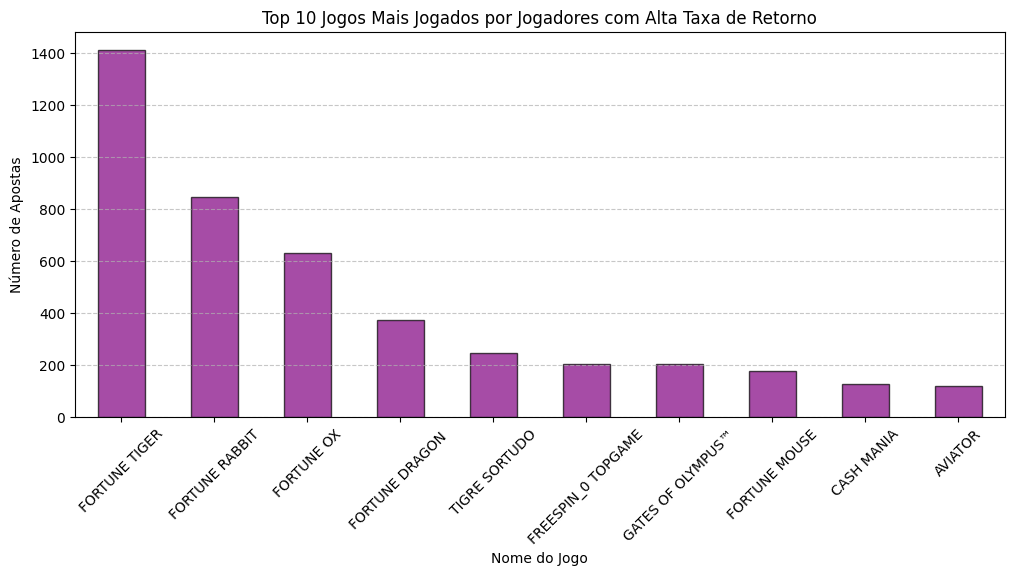

In [ ]:
import matplotlib.pyplot as plt

# Recalcular a taxa de retorno por jogador
taxa_retorno = casino_df.groupby('clientid')[['betamount', 'winamount']].sum()
taxa_retorno['taxa_retorno'] = taxa_retorno['winamount'] / taxa_retorno['betamount']

# Remover casos em que a aposta foi zero para evitar divisão por zero
taxa_retorno = taxa_retorno[taxa_retorno['betamount'] > 0]

# Identificar jogadores com taxa de retorno muito acima do normal (percentil 99)
limite_taxa_suspeita = taxa_retorno['taxa_retorno'].quantile(0.99)
jogadores_suspeitos = taxa_retorno[taxa_retorno['taxa_retorno'] > limite_taxa_suspeita]

# Filtrar os jogadores suspeitos (com alta taxa de retorno)
jogadores_suspeitos_ids = jogadores_suspeitos.index

# Filtrar os jogos mais jogados pelos jogadores suspeitos
jogos_suspeitos = casino_df[casino_df['clientid'].isin(jogadores_suspeitos_ids)]

# Contar a frequência dos jogos mais jogados pelos jogadores suspeitos
jogos_mais_jogados = jogos_suspeitos['gamename'].value_counts().head(10)

# Criar gráfico para visualizar os jogos mais jogados pelos jogadores suspeitos
plt.figure(figsize=(12, 5))
jogos_mais_jogados.plot(kind='bar', color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Nome do Jogo')
plt.ylabel('Número de Apostas')
plt.title('Top 10 Jogos Mais Jogados por Jogadores com Alta Taxa de Retorno')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Exibir os dados dos jogos mais jogados para análise
from IPython.display import display
display(jogos_mais_jogados.to_frame())

,count
gamename,
FORTUNE TIGER,1409
FORTUNE RABBIT,844
FORTUNE OX,631
FORTUNE DRAGON,372
TIGRE SORTUDO,246
FREESPIN_0 TOPGAME,205
GATES OF OLYMPUS™,204
FORTUNE MOUSE,176
CASH MANIA,125


O gráfico e a tabela apresentados mostram os jogos mais explorados pelos jogadores que possuem uma taxa de retorno elevada. Esses jogos podem estar sendo usados estrategicamente para maximizar os ganhos ou, em alguns casos, podem indicar padrões suspeitos de jogo.

- Os jogos da linha "FORTUNE" dominam a lista, com 4 das 5 primeiras posições, sugerindo que esses jogos possuem mecânicas que favorecem jogadores de alto retorno.
- "FORTUNE TIGER" se destaca com mais do que o dobro de apostas em relação ao segundo jogo mais popular entre os jogadores suspeitos.
- "GATES OF OLYMPUS™" e "AVIATOR" também aparecem, embora com menor frequência.
- O jogo "FREESPIN_0 TOPGAME" pode indicar um jogo com mecânica específica de freespins, que pode estar sendo utilizado como uma estratégia para acumular ganhos.

</br>

**Possíveis Explicações para esse Padrão**

Os jogadores estão utilizando uma estratégia específica para maximizar ganhos nesses jogos
 - Pode ser que os jogadores descobriram um padrão vantajoso nesses jogos, seja relacionado às probabilidades, mecânica de freespins ou estratégias de apostas progressivas.


 Os jogos da linha "FORTUNE" podem ter taxas de retorno elevadas
 - Se esses jogos estiverem com um retorno médio maior do que outros jogos, pode ser um indício de que os jogadores estão priorizando esses jogos intencionalmente para aumentar seus lucros.

Possível exploração de vulnerabilidades nos jogos
- Caso haja uma inconsistência na mecânica de algum jogo, jogadores experientes podem estar explorando essas falhas repetidamente.

#### Plano para Definir e Implementar as Regras

Serão criadas três regras principais para identificar jogadores suspeitos:
- Jogadores com Taxa de Retorno Muito Alta
  - A taxa de retorno será calculada para cada jogador:
$$
\text{Taxa de Retorno} = \frac{\sum \text{WinAmount}}{\sum \text{BetAmount}}
$$

  - Jogadores com taxa de retorno acima do percentil 99 serão sinalizados como potenciais exploradores de padrões de jogo.

- Jogadores que Só Apostam em Jogos Específicos de Alta Taxa de Pagamento
  - Serão identificados quais jogos possuem taxas de retorno acima da média.
  - Jogadores que concentram 90% ou mais de suas apostas nesses jogos serão considerados suspeitos.

- Jogadores com Depósitos Altos e Saques Rápidos
  - Para cada jogador, será analisada a relação entre:
$$
\text{Razão de Saque} = \frac{\sum \text{Saque}}{\sum \text{Depósito}}
$$
  - Se a razão de saque for acima de 90%, sem apostas proporcionais, isso pode indicar lavagem de dinheiro ou movimentação suspeita.

In [ ]:
import pandas as pd
import numpy as np

# Recalcular a taxa de retorno por jogador
taxa_retorno = casino_df[['clientid', 'betamount', 'winamount']].groupby('clientid').sum()
taxa_retorno['taxa_retorno'] = taxa_retorno['winamount'] / taxa_retorno['betamount']
taxa_retorno = taxa_retorno[taxa_retorno['betamount'] > 0]  # Remover divisões por zero

# Regra 1: Identificar jogadores com taxa de retorno acima do limite estatístico (percentil 99)
limite_taxa_suspeita = taxa_retorno['taxa_retorno'].quantile(0.99)
jogadores_risco_taxa_retorno = taxa_retorno[taxa_retorno['taxa_retorno'] > limite_taxa_suspeita].index

# Regra 2: Jogadores que apostam em jogos com alta taxa de retorno
retorno_por_jogo = casino_df[['gamename', 'betamount', 'winamount']].groupby('gamename').sum()
retorno_por_jogo['taxa_retorno'] = retorno_por_jogo['winamount'] / retorno_por_jogo['betamount']
limite_jogos_suspeitos = retorno_por_jogo['taxa_retorno'].quantile(0.75)
jogos_suspeitos = retorno_por_jogo[retorno_por_jogo['taxa_retorno'] > limite_jogos_suspeitos].index

# Verificar apenas jogadores relevantes para jogos suspeitos
apostas_relevantes = casino_df[casino_df['gamename'].isin(jogos_suspeitos)][['clientid', 'betamount', 'gamename']]
apostas_por_jogador = apostas_relevantes.groupby(['clientid', 'gamename']).sum().unstack().fillna(0)
percentual_em_jogos_suspeitos = apostas_por_jogador.sum(axis=1) / apostas_por_jogador.sum(axis=1).sum()

jogadores_risco_jogos = percentual_em_jogos_suspeitos[percentual_em_jogos_suspeitos > 0.9].index

# Regra 3: Calcular a razão entre saques e depósitos
transacoes_relevantes = financial_df[financial_df['typename'].isin(['Deposit', 'Withdrawal request Payment'])]
transacoes_por_jogador = transacoes_relevantes.groupby(['clientid', 'typename'])['amount'].sum().unstack().fillna(0)

if 'Deposit' in transacoes_por_jogador.columns and 'Withdrawal request Payment' in transacoes_por_jogador.columns:
    transacoes_por_jogador['ratio_saque'] = (
        transacoes_por_jogador['Withdrawal request Payment'] / transacoes_por_jogador['Deposit']
    )
    jogadores_risco_saques = transacoes_por_jogador[transacoes_por_jogador['ratio_saque'] > 0.9].index
else:
    jogadores_risco_saques = []

# Consolidar jogadores suspeitos
jogadores_suspeitos = set(jogadores_risco_taxa_retorno) | set(jogadores_risco_jogos) | set(jogadores_risco_saques)

# Garantir que apenas jogadores presentes nos DataFrames sejam usados para evitar KeyError
jogadores_validos = np.intersect1d(list(jogadores_suspeitos), taxa_retorno.index)
jogadores_validos = np.intersect1d(jogadores_validos, percentual_em_jogos_suspeitos.index)
jogadores_validos = np.intersect1d(jogadores_validos, transacoes_por_jogador.index)

# Criar DataFrame final apenas com os jogadores válidos
dados_suspeitos = pd.DataFrame(index=jogadores_validos)

# Preencher as colunas com os dados disponíveis
dados_suspeitos['Taxa de Retorno'] = taxa_retorno.loc[dados_suspeitos.index, 'taxa_retorno'].fillna(0)
dados_suspeitos['% de Apostas em Jogos Suspeitos'] = percentual_em_jogos_suspeitos.loc[dados_suspeitos.index].fillna(0)
dados_suspeitos['Razão de Saque'] = transacoes_por_jogador.loc[dados_suspeitos.index, 'ratio_saque'].fillna(0)

In [ ]:
# Exibir os primeiros jogadores suspeitos para validação
from IPython.display import display
display(dados_suspeitos.head(20))

,Taxa de Retorno,% de Apostas em Jogos Suspeitos,Razão de Saque
39843,1.108492,2.366434e-05,2.101999
109472,0.971241,1.083477e-06,1.857143
272984,0.998169,7.485163e-07,1.003156
609460,1.249352,7.017341e-07,2.750000
641714,0.888909,1.622409e-06,1.188645
648044,0.819444,6.390458e-06,0.925061
652822,1.040178,5.613872e-08,1.304348
734590,0.921614,0.000000e+00,1.109446
742189,0.971544,3.747260e-05,0.923358
755074,0.923269,7.358851e-06,1.551247


A tabela mostra os jogadores que foram sinalizados como suspeitos com base nas regras aplicadas. Agora, será analisado se os critérios estão capturando padrões anômalos e se há necessidade de refinamento.

**Análise da Taxa de Retorno**
- A maioria dos jogadores identificados tem taxa de retorno próxima ou superior a 1.0.
- Alguns jogadores têm taxa de retorno acima de 1.30, como os jogadores 609460 (1.249), 1226984 (1.310) e 1470795 (1.346).
- Esses jogadores ganharam mais do que apostaram, o que pode indicar uso de estratégias específicas ou exploração de padrões vantajosos dos jogos.


Interpretação:
  - Jogadores com taxa de retorno acima de 1.0 estão potencialmente explorando padrões favoráveis dos jogos.
  - Caso sejam identificados jogos específicos onde isso ocorre com frequência, pode ser necessária uma revisão na mecânica desses jogos.

**Percentual de Apostas em Jogos Suspeitos**
- O percentual de apostas em jogos suspeitos é muito baixo em todos os casos (valores próximos de 0.000001).
- Isso indica que esses jogadores não estão concentrando suas apostas exclusivamente em jogos de alta taxa de retorno.

Interpretação:
- Nenhum jogador identificado apresenta concentração de apostas em jogos suspeitos.
- Isso sugere que a regra de identificação de jogos suspeitos pode estar muito restritiva e pode precisar de ajustes.

**Razão de Saque**
- Diversos jogadores têm razão de saque acima de 1.0, o que significa que sacaram mais do que depositaram.
- Jogadores como 609460 (2.750), 1470795 (2.562) e 39843 (2.101) sacaram mais de duas vezes o valor depositado, o que pode ser um sinal de lavagem de dinheiro ou movimentações financeiras atípicas.

Interpretação:
- Jogadores com razão de saque muito alta devem ser analisados mais profundamente.
- Possível estratégia: depositar, ganhar um valor pequeno e sacar rapidamente para movimentar dinheiro.

**PARECER FINAL:**

A análise dos jogadores suspeitos revelou três principais pontos:
- A regra de taxa de retorno está funcionando bem, pois identificou jogadores que consistentemente ganham mais do que apostam.
- A regra de apostas em jogos suspeitos pode precisar de ajustes, pois os jogadores identificados não estão concentrando suas apostas nesses jogos.
- A regra de razão de saque identificou possíveis movimentações financeiras suspeitas.

## Conclusão

Este projeto teve como objetivo analisar o comportamento dos jogadores da H2 bet, identificando padrões atípicos de apostas e movimentações financeiras que poderiam indicar possíveis fraudes ou estratégias de exploração do sistema.

Para isso, foram conduzidas diversas análises exploratórias e aplicadas regras estatísticas para a detecção automática de jogadores de risco. O estudo permitiu compreender melhor o comportamento financeiro e estratégico dos usuários, resultando em insights valiosos para a segurança da plataforma.

### Principais descobertas

Jogadores com Alta Taxa de Retorno
- Foram identificados jogadores que consistentemente ganharam mais do que apostaram, com taxas de retorno superiores ao percentil 99% da base. Esse padrão pode indicar uso de estratégias específicas ou exploração de padrões vantajosos de certos jogos.

Padrão de Apostas em Jogos Suspeitos
- A análise demonstrou que os jogadores identificados não estavam exclusivamente concentrando suas apostas em jogos de alta taxa de pagamento. Isso sugere que a regra de detecção pode precisar de ajustes, como reduzir o limite estatístico dos jogos considerados suspeitos para capturar mais casos relevantes.

Movimentações Financeiras Suspeitas
- Foi identificada uma parcela de jogadores que sacaram valores muito superiores aos depósitos realizados. Em alguns casos, a razão de saque ultrapassou 2.5 vezes o valor depositado, o que pode ser um indício de lavagem de dinheiro ou práticas fraudulentas.

### Impacto e Recomendações

- O modelo de regras mostrou-se eficiente na identificação de jogadores com comportamento atípico, permitindo sinalizar possíveis exploradores de padrões e fraudes financeiras.
- A detecção de jogos suspeitos pode ser refinada para capturar melhor jogadores que utilizam estratégias específicas para obter vantagem.
- A relação entre depósitos e saques deve ser monitorada constantemente, pois jogadores que realizam depósitos altos seguidos de saques rápidos sem apostas proporcionais podem estar movimentando dinheiro de forma suspeita.


Com esses insights, a plataforma pode implementar medidas de mitigação, como:

- Revisar a mecânica de jogos que estão sendo explorados.
- Aplicar monitoramento contínuo sobre jogadores com razão de saque elevada.
- Criar regras de alerta para identificar padrões suspeitos automaticamente.

### Fechamento

O estudo realizado foi essencial para fornecer uma visão analítica do comportamento dos jogadores, possibilitando identificar riscos operacionais e oportunidades de otimização da plataforma de jogos.

Com a implementação de estratégias preventivas baseadas nesses dados, a plataforma pode garantir um ambiente mais seguro e equilibrado, reduzindo potenciais fraudes e melhorando a sustentabilidade financeira do negócio.

## Gráficos de apoio para a apresentação

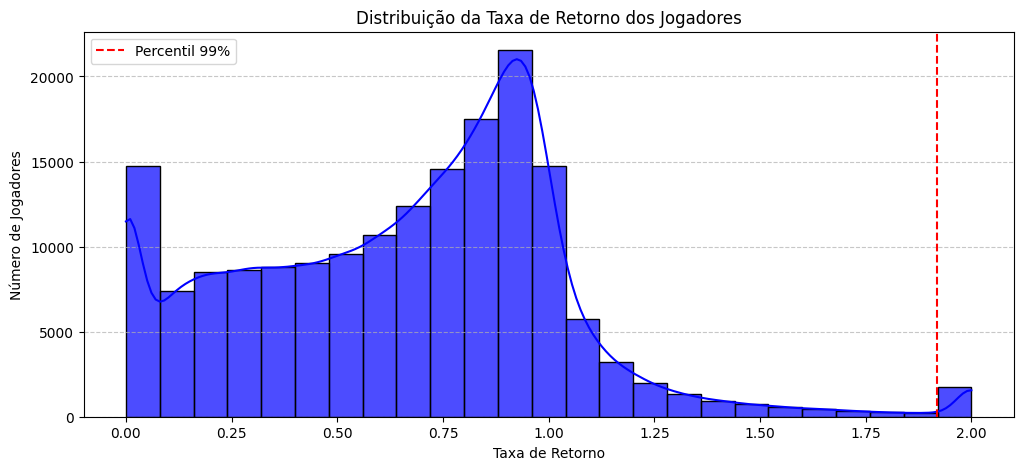

In [ ]:
# Criar uma amostra simulada de taxas de retorno para visualização
taxa_retorno_amostra = taxa_retorno['taxa_retorno'].clip(upper=2.0)  # Limitar valores extremos para melhor visualização

# Criar gráfico de distribuição da taxa de retorno
plt.figure(figsize=(12, 5))
sns.histplot(taxa_retorno_amostra, bins=25, kde=True, color='blue', alpha=0.7)
plt.axvline(taxa_retorno_amostra.quantile(0.99), color='red', linestyle='dashed', label='Percentil 99%')
plt.xlabel('Taxa de Retorno')
plt.ylabel('Número de Jogadores')
plt.title('Distribuição da Taxa de Retorno dos Jogadores')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

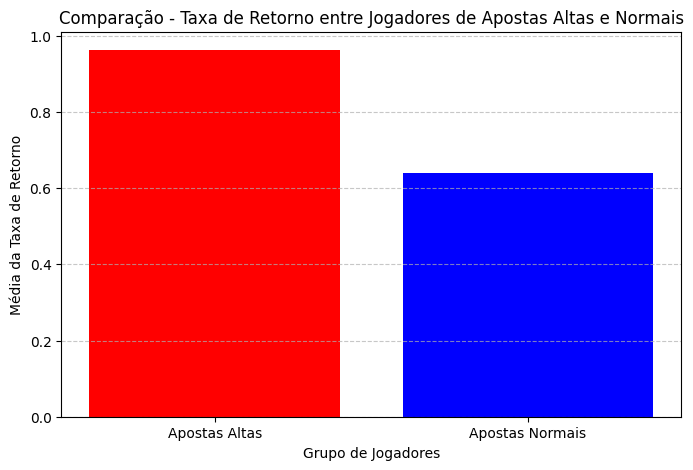

In [ ]:
# Calcular a taxa de retorno por jogador (valor ganho / valor apostado)
taxa_retorno = casino_df.groupby('clientid')[['betamount', 'winamount']].sum()
taxa_retorno['taxa_retorno'] = taxa_retorno['winamount'] / taxa_retorno['betamount']

# Remover casos em que a aposta foi zero para evitar divisão por zero
taxa_retorno = taxa_retorno[taxa_retorno['betamount'] > 0]

# Calcular estatísticas gerais da taxa de retorno
estatisticas_taxa_retorno = taxa_retorno['taxa_retorno'].describe()

# Definir o limite para apostas altas (percentil 99)
limite_aposta_alta = casino_df['betamount'].quantile(0.99)

# Identificar jogadores de apostas elevadas
jogadores_apostas_altas = casino_df.groupby('clientid')['betamount'].sum()
jogadores_apostas_altas = jogadores_apostas_altas[jogadores_apostas_altas > limite_aposta_alta]

# Comparar a taxa de retorno entre jogadores normais e jogadores de apostas elevadas
taxa_retorno_jogadores_altos = taxa_retorno.loc[jogadores_apostas_altas.index]
taxa_retorno_normais = taxa_retorno.loc[~taxa_retorno.index.isin(jogadores_apostas_altas.index)]

# Calcular médias de taxa de retorno
media_taxa_retorno_altos = taxa_retorno_jogadores_altos['taxa_retorno'].mean()
media_taxa_retorno_normais = taxa_retorno_normais['taxa_retorno'].mean()

# Criar gráfico para comparar a taxa de retorno média entre os grupos
plt.figure(figsize=(8, 5))
plt.bar(['Apostas Altas', 'Apostas Normais'], [media_taxa_retorno_altos, media_taxa_retorno_normais], color=['red', 'blue'])
plt.xlabel('Grupo de Jogadores')
plt.ylabel('Média da Taxa de Retorno')
plt.title('Comparação - Taxa de Retorno entre Jogadores de Apostas Altas e Normais')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()